# Dự đoán lỗi phần mềm trên bộ dữ liệu NASA/PROMISE đã gộp

## 1. Giới thiệu

Notebook này trình bày một nghiên cứu tình huống hoàn chỉnh về Dự đoán lỗi phần mềm (Software Defect Prediction - SDP) sử dụng bộ dữ liệu NASA/PROMISE đã gộp từ 9 dataset chính có chung 21 metric phần mềm. Để giảm thời gian chạy, notebook lấy mẫu stratified 5,000 dòng từ file dữ liệu đã gộp và giữ tỷ lệ lớp lỗi gần với dữ liệu gốc. Mục tiêu của nghiên cứu là so sánh hiệu suất dự đoán giữa các bộ phân loại đơn lẻ (single classifiers) và các bộ phân loại tổ hợp (ensemble classifiers) trong việc xác định các mô-đun phần mềm bị lỗi.

Quy trình gồm: phân tích khám phá dữ liệu, tiền xử lý dữ liệu, xử lý mất cân bằng lớp bằng SMOTE, huấn luyện mô hình với Stratified 10-Fold Cross Validation, và đánh giá so sánh bằng các độ đo có trọng số.

Các mô hình được đánh giá gồm:

- Decision Tree
- Logistic Regression
- Support Vector Machine
- Random Forest
- AdaBoost
- Bagging

Notebook được xây dựng hoàn chỉnh, độc lập và có thể chạy tuần tự từ đầu đến cuối.


## 2. Import thư viện

Cell dưới đây import toàn bộ thư viện cần thiết cho xử lý dữ liệu, trực quan hóa, xử lý mất cân bằng, huấn luyện mô hình và đánh giá kết quả.

In [ ]:
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.base import clone
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['savefig.dpi'] = 300

RANDOM_STATE = 42
DATA_PATH = Path('data.csv')
TARGET_COLUMN = 'Defective'
SAMPLE_SIZE = 5000


## 3. Nạp dữ liệu

Mục này nạp file `data.csv`, sau đó lấy mẫu stratified 5,000 dòng theo cột nhãn `Defective` để giảm thời gian huấn luyện nhưng vẫn giữ tỷ lệ lớp.


In [ ]:
full_df = pd.read_csv(DATA_PATH)

if len(full_df) > SAMPLE_SIZE:
    raw_df, _ = train_test_split(
        full_df,
        train_size=SAMPLE_SIZE,
        stratify=full_df[TARGET_COLUMN],
        random_state=RANDOM_STATE,
    )
    raw_df = raw_df.sort_index().reset_index(drop=True)
else:
    raw_df = full_df.copy()

print(f'Full shape: {full_df.shape}')
print(f'Sampled shape: {raw_df.shape}')
raw_df.head()


## 4. Phân tích khám phá dữ liệu (EDA)

Trước tiên, ta xem lược đồ dữ liệu, xác định các vấn đề chất lượng dữ liệu và kiểm tra phân bố lớp giữa mô-đun lỗi và không lỗi.

In [ ]:
raw_df.info()

In [ ]:
raw_df.describe(include='all').T

In [ ]:
target_distribution = raw_df[TARGET_COLUMN].value_counts(dropna=False).sort_index()
target_ratio = raw_df[TARGET_COLUMN].value_counts(normalize=True).sort_index()
display(pd.DataFrame({
    'count': target_distribution,
    'ratio': target_ratio.round(4)
}).rename(index={0: 'Non-defective', 1: 'Defective'}));

plt.figure(figsize=(7, 5))
class_labels = raw_df[TARGET_COLUMN].map({0: 'Non-defective', 1: 'Defective'})
sns.countplot(x=class_labels, hue=class_labels, palette=['#0b6e4f', '#c1121f'], legend=False)
plt.title('Class Distribution in Merged NASA/PROMISE Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Modules')
plt.show()


In [ ]:
quality_report = []
for col in raw_df.columns:
    question_marks = int((raw_df[col].astype(str) == '?').sum())
    quality_report.append({
        'column': col,
        'dtype': str(raw_df[col].dtype),
        'missing_values': int(raw_df[col].isna().sum()),
        'question_mark_values': question_marks,
    })
quality_report_df = pd.DataFrame(quality_report)
question_mark_columns = quality_report_df.loc[
    quality_report_df['question_mark_values'] > 0,
    'column'
].tolist()
quality_report_df[(quality_report_df['missing_values'] > 0) | (quality_report_df['question_mark_values'] > 0)]


In [ ]:
eda_numeric = raw_df.copy()
for col in question_mark_columns:
    eda_numeric[col] = pd.to_numeric(eda_numeric[col], errors='coerce')
eda_numeric[TARGET_COLUMN] = eda_numeric[TARGET_COLUMN].astype(int)

plt.figure(figsize=(14, 10))
corr = eda_numeric.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, linewidths=0.2, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Merged NASA/PROMISE Software Metrics')
plt.show()


## 5. Tiền xử lý dữ liệu

Bộ dữ liệu có một số cột metric đang ở dạng chuỗi do chứa giá trị thay thế `?`. Các giá trị này được chuyển thành `NaN`, sau đó điền khuyết bằng median để giữ lại toàn bộ quan sát. Biến mục tiêu cũng được chuyển sang dạng nhị phân số để huấn luyện mô hình.

In [ ]:
def clean_defect_dataset(df: pd.DataFrame, target_column: str = TARGET_COLUMN) -> tuple[pd.DataFrame, pd.DataFrame]:
    cleaned = df.copy()
    report = []
    for col in cleaned.columns:
        if col != target_column:
            before_missing = int(cleaned[col].isna().sum())
            cleaned[col] = pd.to_numeric(cleaned[col], errors='coerce')
            after_coerce_missing = int(cleaned[col].isna().sum())
            imputed = after_coerce_missing
            if cleaned[col].isna().any():
                cleaned[col] = cleaned[col].fillna(cleaned[col].median())
            report.append({
                'column': col,
                'missing_before': before_missing,
                'missing_after_coercion': after_coerce_missing,
                'imputed_values': imputed,
            })
    cleaned[target_column] = cleaned[target_column].astype(int)
    return cleaned, pd.DataFrame(report)

clean_df, preprocessing_report = clean_defect_dataset(raw_df)
print(f'Cleaned shape: {clean_df.shape}')
clean_df.head()


In [ ]:
preprocessing_report[preprocessing_report['imputed_values'] > 0]

In [ ]:
dataset_summary = pd.DataFrame({
    'Statistic': [
        'Number of instances',
        'Number of features',
        'Defective modules',
        'Non-defective modules',
        'Defective ratio',
        'Non-defective ratio',
        'Remaining missing values',
    ],
    'Value': [
        len(clean_df),
        clean_df.shape[1] - 1,
        int(clean_df[TARGET_COLUMN].sum()),
        int((1 - clean_df[TARGET_COLUMN]).sum()),
        round(clean_df[TARGET_COLUMN].mean(), 4),
        round(1 - clean_df[TARGET_COLUMN].mean(), 4),
        int(clean_df.isna().sum().sum()),
    ]
})
dataset_summary


## 6. Xử lý mất cân bằng lớp bằng SMOTE

Vì số mô-đun bị lỗi là lớp thiểu số, nghiên cứu sử dụng **SMOTE (Synthetic Minority Over-sampling Technique)**. Để tránh rò rỉ dữ liệu, SMOTE chỉ được áp dụng **trên các tập train của từng fold** trong cross-validation, không áp dụng trên toàn bộ dữ liệu trước khi chia tập.

In [ ]:
X = clean_df.drop(columns=[TARGET_COLUMN])
y = clean_df[TARGET_COLUMN]

print('Original class distribution:')
print(y.value_counts())

scaler_demo = StandardScaler()
X_scaled_demo = scaler_demo.fit_transform(X)
smote_demo = SMOTE(random_state=RANDOM_STATE)
X_smote_demo, y_smote_demo = smote_demo.fit_resample(X_scaled_demo, y)
print('\nSMOTE demo distribution:')
print(pd.Series(y_smote_demo).value_counts())


## 7. Định nghĩa mô hình

Mục này định nghĩa các mô hình đơn lẻ (base learners) và mô hình tổ hợp (ensemble learners) dùng trong so sánh. Các mô hình được chọn bám sát tài liệu chuẩn về software defect prediction và phù hợp với dữ liệu dạng bảng dựa trên metric.

In [ ]:
def build_models() -> Dict[str, object]:
    return {
        'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, random_state=RANDOM_STATE),
        'Logistic Regression': LogisticRegression(C=1.0, solver='liblinear', max_iter=2000, random_state=RANDOM_STATE),
        'SVM': SVC(C=1.0, kernel='rbf', gamma='scale', probability=True, random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(n_estimators=300, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=1),
        'AdaBoost': AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=RANDOM_STATE),
        'Bagging': BaggingClassifier(
            estimator=DecisionTreeClassifier(min_samples_leaf=2, random_state=RANDOM_STATE),
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
    }

models = build_models()
list(models.keys())

## 8. Huấn luyện mô hình bằng Stratified 10-Fold Cross Validation

Các hàm dưới đây triển khai đúng giao thức thực nghiệm. Mỗi fold thực hiện chuẩn hóa dữ liệu, oversampling bằng SMOTE trên train fold, huấn luyện mô hình, dự đoán nhãn và ước lượng xác suất để phân tích ROC.

In [ ]:
def score_fold(y_true, y_pred, y_score):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_score),
    }

def evaluate_models_cv(X: pd.DataFrame, y: pd.Series, models: Dict[str, object], n_splits: int = 10):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    smote = SMOTE(random_state=RANDOM_STATE)
    mean_fpr = np.linspace(0, 1, 200)
    fold_records = []
    roc_records = []
    confusion_records = []
    final_models = {}

    for model_name, model in models.items():
        print(f'Evaluating {model_name}...')
        tprs = []
        cm_sum = np.zeros((2, 2), dtype=int)

        for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)

            X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

            fitted_model = clone(model)
            fitted_model.fit(X_train_resampled, y_train_resampled)

            y_pred = fitted_model.predict(X_test_scaled)
            if hasattr(fitted_model, 'predict_proba'):
                y_score = fitted_model.predict_proba(X_test_scaled)[:, 1]
            else:
                decision = fitted_model.decision_function(X_test_scaled)
                y_score = (decision - decision.min()) / (decision.max() - decision.min() + 1e-12)

            metrics = score_fold(y_test, y_pred, y_score)
            metrics.update({'model': model_name, 'fold': fold_idx})
            fold_records.append(metrics)

            cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
            cm_sum += cm

            fpr, tpr, _ = roc_curve(y_test, y_score)
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            tprs.append(interp_tpr)

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        roc_records.append(pd.DataFrame({'model': model_name, 'fpr': mean_fpr, 'tpr': mean_tpr}))
        confusion_records.append({
            'model': model_name,
            'tn': int(cm_sum[0, 0]),
            'fp': int(cm_sum[0, 1]),
            'fn': int(cm_sum[1, 0]),
            'tp': int(cm_sum[1, 1]),
        })

        final_scaler = StandardScaler()
        X_scaled_full = final_scaler.fit_transform(X)
        X_full_resampled, y_full_resampled = smote.fit_resample(X_scaled_full, y)
        final_model = clone(model)
        final_model.fit(X_full_resampled, y_full_resampled)
        final_models[model_name] = {'model': final_model, 'scaler': final_scaler}

    fold_metrics_df = pd.DataFrame(fold_records)
    summary_df = (
        fold_metrics_df.groupby('model')
        .agg(
            accuracy_mean=('accuracy', 'mean'),
            accuracy_std=('accuracy', 'std'),
            precision_weighted_mean=('precision_weighted', 'mean'),
            recall_weighted_mean=('recall_weighted', 'mean'),
            f1_weighted_mean=('f1_weighted', 'mean'),
            roc_auc_mean=('roc_auc', 'mean'),
        )
        .reset_index()
        .sort_values(by='f1_weighted_mean', ascending=False)
    )

    return {
        'fold_metrics': fold_metrics_df,
        'summary_metrics': summary_df,
        'roc_curve': pd.concat(roc_records, ignore_index=True),
        'confusion_matrix': pd.DataFrame(confusion_records),
        'final_models': final_models,
    }

In [126]:
results = evaluate_models_cv(X, y, models, n_splits=10)
fold_metrics_df = results['fold_metrics']
summary_metrics_df = results['summary_metrics']
roc_curve_df = results['roc_curve']
confusion_df = results['confusion_matrix']

summary_metrics_df

,model,accuracy_mean,accuracy_std,precision_weighted_mean,recall_weighted_mean,f1_weighted_mean,roc_auc_mean
4,Random Forest,0.815607,0.011879,0.800271,0.815607,0.806104,0.772213
1,Bagging,0.818043,0.008300,0.796911,0.818043,0.804266,0.759176
3,Logistic Regression,0.724663,0.008568,0.785358,0.724663,0.747326,0.711726
5,SVM,0.721109,0.009665,0.791987,0.721109,0.746264,0.722637
2,Decision Tree,0.694062,0.016853,0.776752,0.694062,0.723364,0.698109
0,AdaBoost,0.669715,0.019105,0.787458,0.669715,0.706168,0.714363


## 9. Đánh giá mô hình

Bảng dưới đây thể hiện giá trị trung bình các độ đo có trọng số trên 10 folds. Các độ đo weighted được dùng để phản ánh đúng hơn trong bối cảnh dữ liệu mất cân bằng lớp.

In [127]:
summary_metrics_df.style.format({
    'accuracy_mean': '{:.4f}',
    'accuracy_std': '{:.4f}',
    'precision_weighted_mean': '{:.4f}',
    'recall_weighted_mean': '{:.4f}',
    'f1_weighted_mean': '{:.4f}',
    'roc_auc_mean': '{:.4f}',
})

,model,accuracy_mean,accuracy_std,precision_weighted_mean,recall_weighted_mean,f1_weighted_mean,roc_auc_mean
4,Random Forest,0.8156,0.0119,0.8003,0.8156,0.8061,0.7722
1,Bagging,0.8180,0.0083,0.7969,0.8180,0.8043,0.7592
3,Logistic Regression,0.7247,0.0086,0.7854,0.7247,0.7473,0.7117
5,SVM,0.7211,0.0097,0.7920,0.7211,0.7463,0.7226
2,Decision Tree,0.6941,0.0169,0.7768,0.6941,0.7234,0.6981
0,AdaBoost,0.6697,0.0191,0.7875,0.6697,0.7062,0.7144


## 10. Trực quan hóa

Mục này trực quan hóa hiệu suất so sánh giữa các bộ phân loại thông qua confusion matrix, ROC curve, so sánh accuracy và so sánh weighted F1-score.

/var/folders/0j/3mt0xrl50ygbd0938sghsln80000gp/T/ipykernel_58105/90307639.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='accuracy_mean', y='model', palette='viridis')


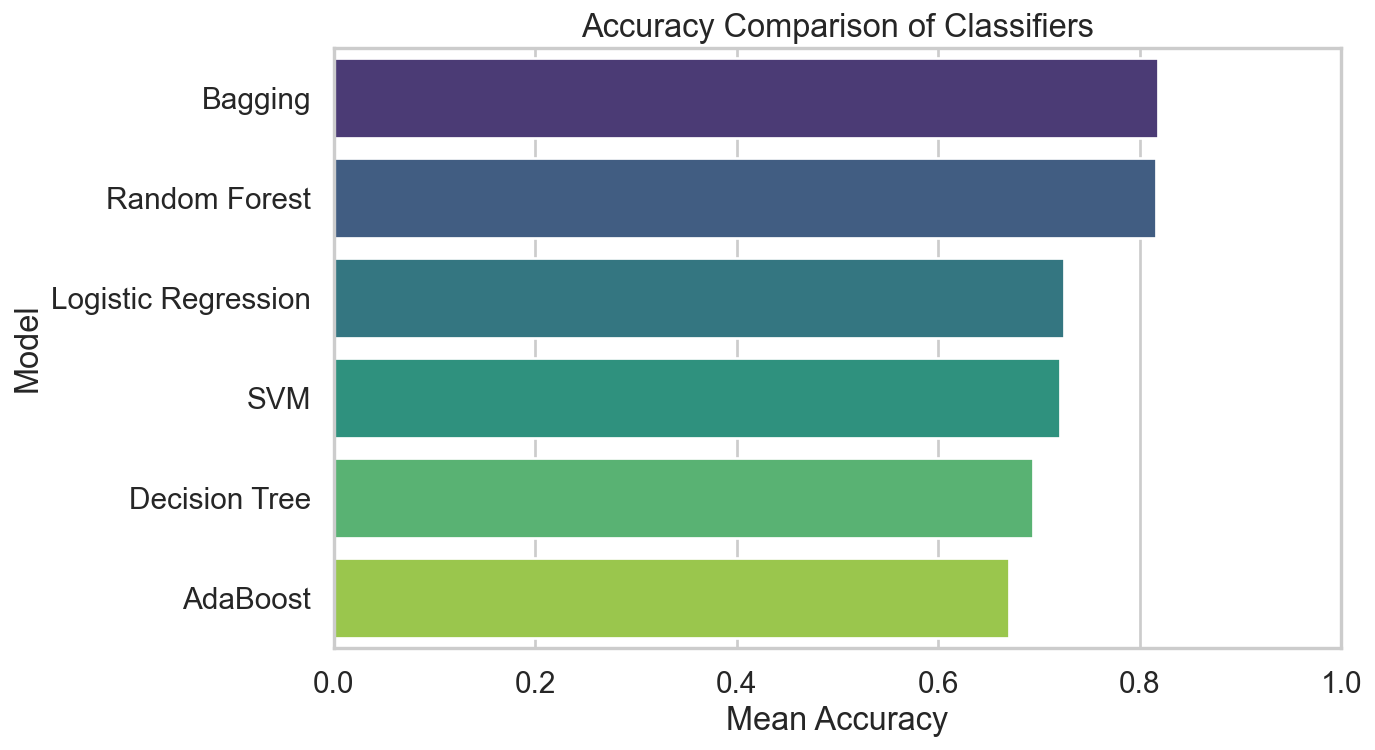

In [128]:
plt.figure(figsize=(10, 6))
plot_df = summary_metrics_df.sort_values(by='accuracy_mean', ascending=False)
sns.barplot(data=plot_df, x='accuracy_mean', y='model', palette='viridis')
plt.title('Accuracy Comparison of Classifiers')
plt.xlabel('Mean Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.show()

/var/folders/0j/3mt0xrl50ygbd0938sghsln80000gp/T/ipykernel_58105/393170254.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='f1_weighted_mean', y='model', palette='mako')


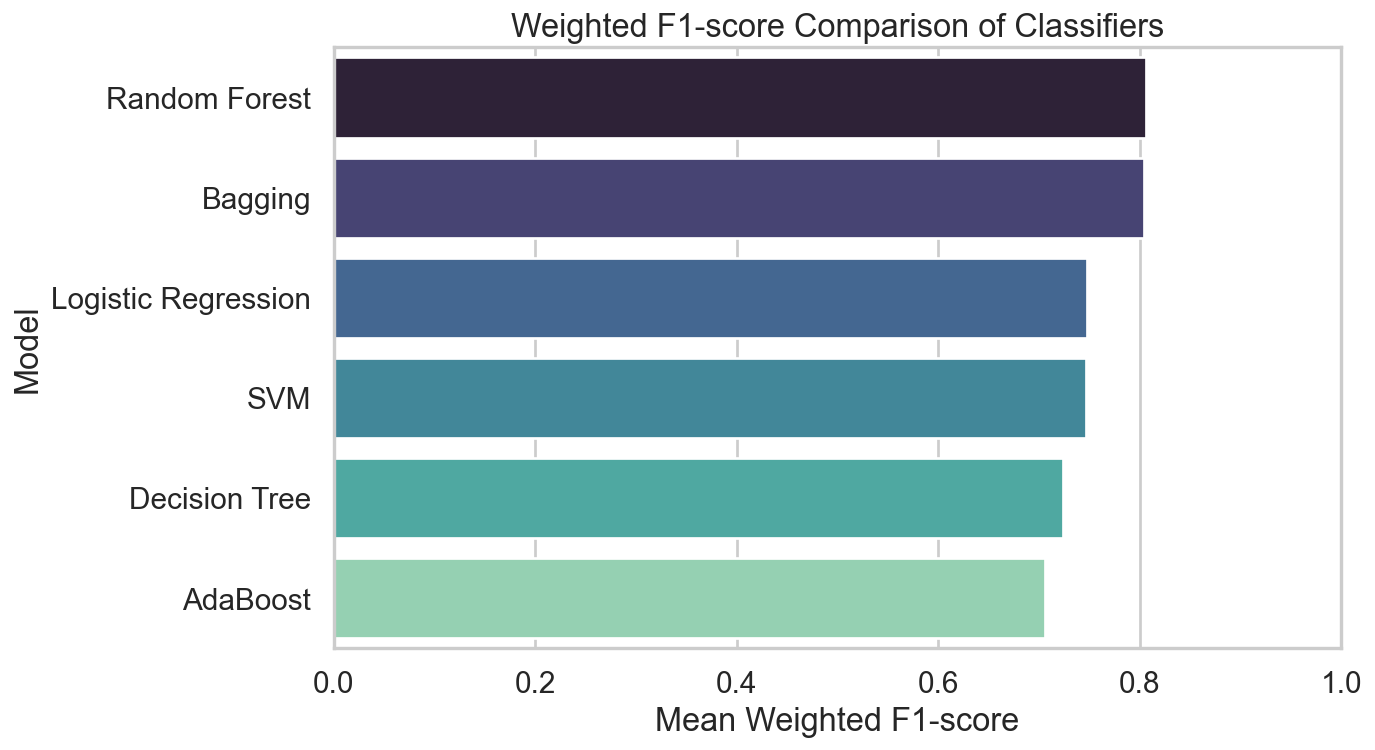

In [129]:
plt.figure(figsize=(10, 6))
plot_df = summary_metrics_df.sort_values(by='f1_weighted_mean', ascending=False)
sns.barplot(data=plot_df, x='f1_weighted_mean', y='model', palette='mako')
plt.title('Weighted F1-score Comparison of Classifiers')
plt.xlabel('Mean Weighted F1-score')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.show()

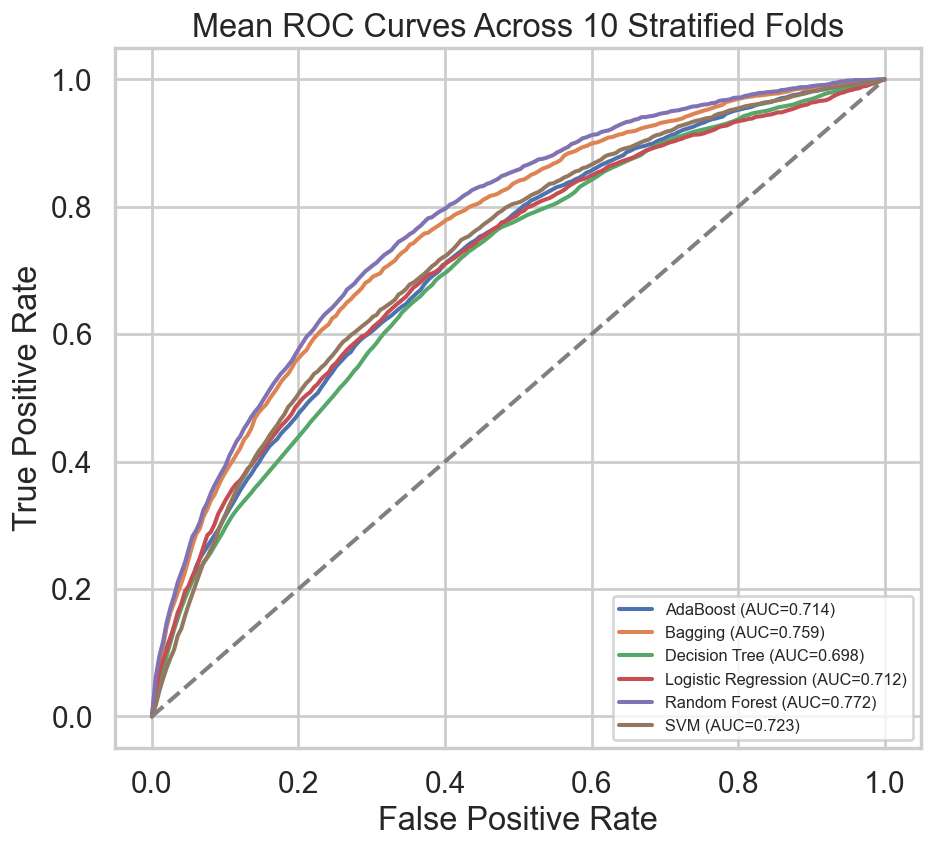

In [130]:
plt.figure(figsize=(8, 7))
auc_map = summary_metrics_df.set_index('model')['roc_auc_mean'].to_dict()
for model_name, group in roc_curve_df.groupby('model'):
    plt.plot(group['fpr'], group['tpr'], label=f"{model_name} (AUC={auc_map[model_name]:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Mean ROC Curves Across 10 Stratified Folds')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize=9)
plt.show()

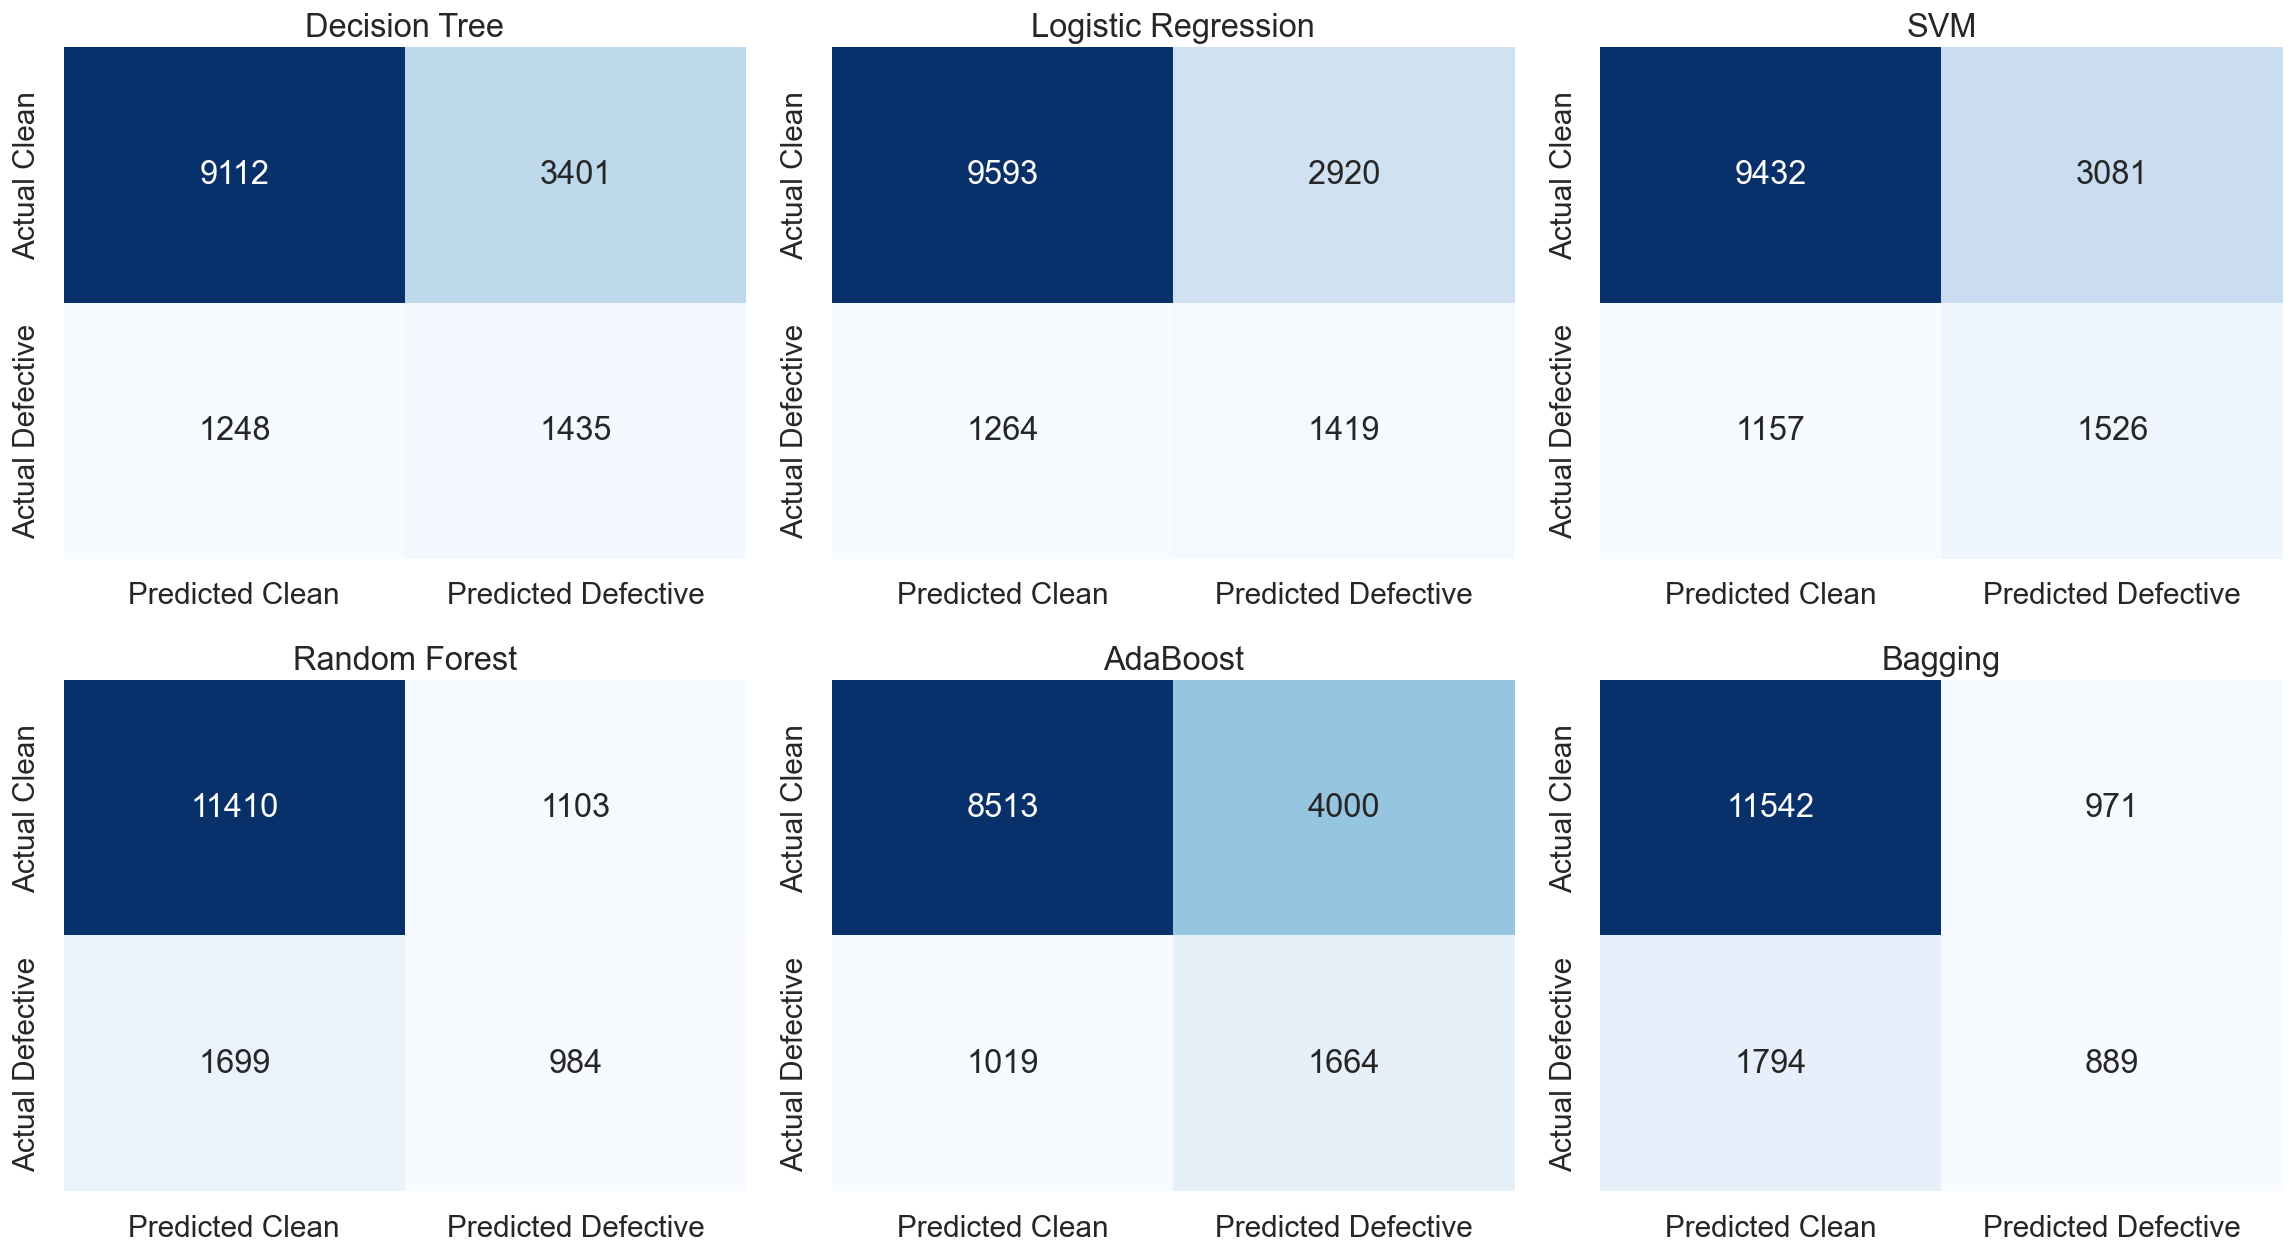

In [131]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for ax, (_, row) in zip(axes, confusion_df.iterrows()):
    matrix = np.array([[row['tn'], row['fp']], [row['fn'], row['tp']]])
    sns.heatmap(
        matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax,
        xticklabels=['Predicted Clean', 'Predicted Defective'],
        yticklabels=['Actual Clean', 'Actual Defective'],
    )
    ax.set_title(row['model'])
plt.tight_layout()
plt.show()

/var/folders/0j/3mt0xrl50ygbd0938sghsln80000gp/T/ipykernel_58105/3903375996.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(12).sort_values(by='importance'), x='importance', y='feature', palette='crest')


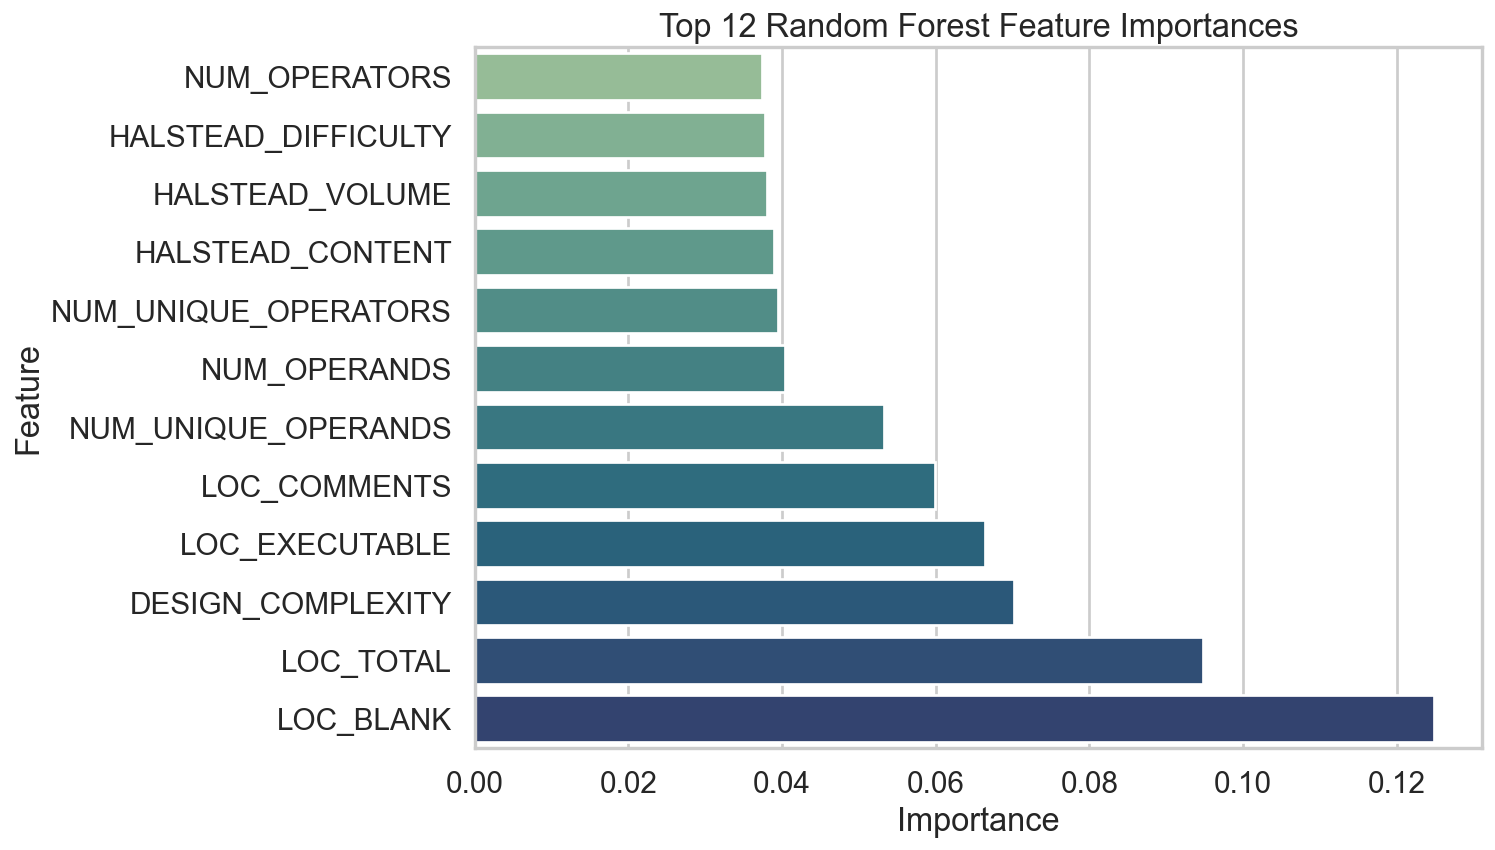

,feature,importance
0,LOC_BLANK,0.124851
20,LOC_TOTAL,0.094728
5,DESIGN_COMPLEXITY,0.070186
7,LOC_EXECUTABLE,0.066423
3,LOC_COMMENTS,0.059869
18,NUM_UNIQUE_OPERANDS,0.053241
16,NUM_OPERANDS,0.040419
19,NUM_UNIQUE_OPERATORS,0.039412
8,HALSTEAD_CONTENT,0.038918
15,HALSTEAD_VOLUME,0.038029


In [132]:
rf_model = results['final_models']['Random Forest']['model']
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=feature_importance_df.head(12).sort_values(by='importance'), x='importance', y='feature', palette='crest')
plt.title('Top 12 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

feature_importance_df.head(12)

## 11. Kết quả và thảo luận

Cell dưới đây xác định mô hình tốt nhất theo weighted F1-score và đưa ra phần tóm tắt ngắn gọn về thứ hạng các mô hình.

In [133]:
best_model_row = summary_metrics_df.iloc[0]
best_model_row

model                      Random Forest
accuracy_mean                   0.815607
accuracy_std                    0.011879
precision_weighted_mean         0.800271
recall_weighted_mean            0.815607
f1_weighted_mean                0.806104
roc_auc_mean                    0.772213
Name: 4, dtype: object